In [4]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
from typing import Iterable, Sequence, Mapping
import os 
import glob 
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.colors import Normalize
from matplotlib.colors import BoundaryNorm, ListedColormap, LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm


In [51]:
@dataclass(frozen=True)
class S2SSkillPlotConfig:
    """Plot config for s2s_skill_<GROUP>_<FREQ>_<RUN>_<OBS>_<REGION>_<VAR>.nc style files."""
    skill_dir: Path
    file_glob: str = "s2s_skill_*_*.nc"
    default_obs : str = "ERA5"
    obs_by_var: dict[str, str] = field(default_factory=dict)  # <-- fix here
    
    # What to plot
    vars_include: tuple[str, ...] = ()
    exp_include: tuple[str, ...] = ()
    exp_order: tuple[str, ...] = ()

    # NEW: region selection (if you have multiple regions)
    regions_include: tuple[str, ...] = ()  # if empty -> all regions found
    region_order: tuple[str, ...] = ()     # optional explicit ordering

    # Lead bins (days since init); use lead_days coordinate
    lead_bins: tuple[tuple[int, int], ...] = ((1, 14), (15, 28), (29, 42), (43, 56))
    lead_bin_labels: tuple[str, ...] = ("Wk1–2", "Wk3–4", "Wk5–6", "Wk7–8")

    # Curves
    smooth_days: int = 7
    time_max: int | None = None

    # Bars
    bar_metric: str = "ACC"
    bar_use_quantiles: bool = True
    debug: bool = True
    two_groups : bool = False 
    plot_difference: bool = False 

    # Line plot meaning
    line_type: str = "ens_mean"

    # Style
    figsize_curve: tuple[float, float] = (10.5, 4.2)
    figsize_bar: tuple[float, float] = (11.5, 4.8)
    legend_ncol: int = 4

    # Output
    out_dir: Path | None = None
    dpi: int = 300
    tag: str = ""
    
    # styling controls
    exp_colors: Mapping[str, str] | None = None
    xlim: tuple[float, float] | None = None
    ylim: tuple[float, float] | None = None
    
    lead_join: str = "inner"  # "inner" (common leads) or "outer" (union leads, NaN padded)
    quantile_q: float | None = None   # e.g., 0.90
    quantile_tol: float = 1e-3
    
    baseline_exp: str | None = None
    rmse_norm_mode: str | None = "baseline"  # None | "baseline"
    rmse_norm_baseline_exp: str | None = None  # if None, use baseline_exp passed to plot call
    rmse_eps: float = 1e-12  # avoid divide-by-zero
    rmse_norm_ctrl_by_group: dict[str, str] = field(default_factory=lambda: {
        "Jan2012": "CTRL10-S0",
        "Jun2012": "CTRL10-S1",
    })
    
# ----------------------------
# Plotter
# ----------------------------
class S2SSkillPlotter:
    """
    Reads s2s_skill_*.nc files (one var per file) with dims:
      time, exp, var(=1), ens, q(=3)

    vars:
      ACC(var, exp, time), RMSE(...)
      ACC_member_std(var, exp, time), ...
      ACC_member_mean(var, exp, time), ...
      ACC_member_quantile(q, var, exp, time), ...
      lead_days(time)

    NEW: supports multiple regions by parsing filename:
      ..._<REGION>_<VAR>.nc
    """

    def __init__(self, cfg: S2SSkillPlotConfig):
        self.cfg = cfg
        if self.cfg.out_dir:
            self.cfg.out_dir.mkdir(parents=True, exist_ok=True)
        self._files_cache: list[Path] | None = None
        self._two_group_cache: dict[tuple[str, str | None], xr.Dataset] = {}

    # ---------- IO helpers ----------
    def _discover_files(self) -> list[Path]:
        if self._files_cache is None:
            files = sorted(self.cfg.skill_dir.glob(self.cfg.file_glob))
            if not files:
                raise FileNotFoundError(f"No files matched {self.cfg.skill_dir}/{self.cfg.file_glob}")
            self._files_cache = files
        return self._files_cache

    @staticmethod
    def _parse_tokens(p: Path) -> list[str]:
        # split stem by "_" for filename parsing
        return p.stem.split("_")
        
    def _parse_obs_var(self, p: Path) -> tuple[str, str]:
        stem = p.stem  # no .nc
        parts = stem.split("_")
        # expected: s2s skill <group> <freq> <run> <obs> <var>
        #          0   1     2       3     4     5     6
        if len(parts) < 7:
            raise ValueError(f"Unexpected filename format: {p.name}")
        obs = parts[-2]
        var = parts[-1]
        return obs, var
    
    def _var_from_filename(self, p: Path) -> str:
        return self._parse_obs_var(p)[1]
    
    def _obs_from_filename(self, p: Path) -> str:
        return self._parse_obs_var(p)[0]

    def list_vars(self) -> list[str]:
        files = self._discover_files()
        vars_ = [self._var_from_filename(p) for p in files]
        if self.cfg.vars_include:
            vars_ = [v for v in vars_ if v in set(self.cfg.vars_include)]
        return sorted(dict.fromkeys(vars_))

    def list_regions(self, var_name: str | None = None) -> list[str]:
        """
        Regions are stored inside the dataset as a dimension/coord 'region'.
        If var_name is None, use the first available var file to read region list.
        """
        vars_ = self.list_vars()
        if not vars_:
            raise ValueError("No variables found to infer regions.")
    
        v0 = var_name or vars_[0]
        ds0 = self.open_skill(v0, region=None, debug=self.cfg.debug)  # open all regions
    
        if "region" not in ds0.dims and "region" not in ds0.coords:
            raise KeyError(
                f"No 'region' dimension found in dataset for var={v0}. "
                f"dims={dict(ds0.dims)} coords={list(ds0.coords)}"
            )
    
        regs = [str(r) for r in ds0["region"].values.tolist()]
    
        # optional include filter
        if self.cfg.regions_include:
            regs = [r for r in regs if r in set(self.cfg.regions_include)]
    
        # optional explicit order
        if self.cfg.region_order:
            regs = [r for r in self.cfg.region_order if r in set(regs)]
        else:
            regs = sorted(dict.fromkeys(regs))
    
        return regs


    def _select_exps(self, ds: xr.Dataset) -> xr.Dataset:
        if "exp" not in ds:
            return ds
        exps = [str(e) for e in ds["exp"].values.tolist()]
        if self.cfg.exp_include:
            keep = [e for e in exps if e in set(self.cfg.exp_include)]
        else:
            keep = exps
        if self.cfg.exp_order:
            keep = [e for e in self.cfg.exp_order if e in set(keep)]
        if not keep:
            raise ValueError(
                "No experiments selected. Check exp_order/exp_include vs file's exp names. "
                f"File exps={exps}, requested exp_order={list(self.cfg.exp_order)}"
            )
        return ds.sel(exp=keep)

    @staticmethod
    def _rolling_mean(da: xr.DataArray, win: int) -> xr.DataArray:
        if win is None or win <= 1:
            return da
        return da.rolling(time=win, center=True, min_periods=1).mean()

    def _maybe_cap_time(self, ds: xr.Dataset) -> xr.Dataset:
        if self.cfg.time_max is None:
            return ds
        lead = self._get_lead_days(ds)
        return ds.sel(time=lead <= float(self.cfg.time_max))

    def _apply_axes_limits(self, ax: plt.Axes) -> None:
        if self.cfg.xlim is not None:
            ax.set_xlim(*self.cfg.xlim)
        if self.cfg.ylim is not None:
            ax.set_ylim(*self.cfg.ylim)

    # ---------- binning helpers ----------
    def _bin_mask(self, lead: xr.DataArray, a: int, b: int) -> xr.DataArray:
        return (lead >= float(a)) & (lead <= float(b))

    def _bin_mean(self, da: xr.DataArray, lead: xr.DataArray, a: int, b: int) -> xr.DataArray:
        m = self._bin_mask(lead, a, b)
        # average along the same dimension that 'lead' lives on (time or lead)
        dim = lead.dims[0]
        return da.where(m).mean(dim, skipna=True)
        
    def _obs_for_var(self, var_name: str) -> str:
        return self.cfg.obs_by_var.get(var_name, self.cfg.default_obs)

    def _standardize_to_lead(self, ds: xr.Dataset) -> xr.Dataset:
        """
        Convert dataset from init-date-dependent 'time' to init-independent 'lead' coordinate.
        Works for dims like (..., time) and keeps region dimension untouched.
        """
        if "lead_days" not in ds:
            raise KeyError("Expected 'lead_days(time)' in dataset.")
    
        # make a new coordinate named 'lead' (float) attached to the time dimension
        lead = ds["lead_days"].astype(float)
        ds = ds.assign_coords(lead=("time", lead.values))
    
        # swap time-dimension to lead-dimension
        ds = ds.swap_dims({"time": "lead"})
    
        # drop init-date-dependent absolute time coordinate/var (safe)
        ds = ds.drop_vars(["time"], errors="ignore")
    
        return ds
        
    def _standardize_lead_dim(self, ds: xr.Dataset) -> xr.Dataset:
        """
        Ensure we have a common 'lead' dimension for aligning Jan/Jun,
        independent of differing 'time:units' in the files.
        """
        if "lead_days" not in ds:
            raise KeyError("Expected 'lead_days' in dataset.")
    
        # Rename time->lead (dimension), keep lead values from lead_days
        if "time" in ds.dims:
            ds = ds.assign_coords(lead=("time", ds["lead_days"].astype(float).values))
            ds = ds.swap_dims({"time": "lead"}).drop_vars("time", errors="ignore")
        elif "lead" in ds.dims:
            # already standardized
            if "lead" not in ds.coords:
                ds = ds.assign_coords(lead=ds["lead_days"].astype(float))
        else:
            raise KeyError("Expected either 'time' or 'lead' dimension in dataset.")
    
        # after swap, lead_days is redundant (but keep if you like)
        # ds = ds.drop_vars("lead_days", errors="ignore")
    
        # Ensure monotonic lead
        ds = ds.sortby("lead")
        return ds
    
    
    def _select_region_if_needed(self, ds: xr.Dataset, region: str | None) -> xr.Dataset:
        if region is None:
            return ds
    
        if "region" in ds.dims or "region" in ds.coords:
            return ds.sel(region=region)
        if "region" in ds.variables:
            return ds.set_coords("region").sel(region=region)
    
        raise KeyError("Requested region selection, but dataset has no 'region' dim/coord.")
    

    @staticmethod
    def _get_lead_days(ds: xr.Dataset) -> xr.DataArray:
        # prefer the lead coordinate once standardized
        if "lead" in ds.coords:
            return ds["lead"].astype(float)
        if "lead_days" in ds:
            return ds["lead_days"].astype(float)
        if "time" in ds.dims:
            return xr.DataArray(np.arange(ds.sizes["time"], dtype=float), dims=("time",), name="lead_days")
        raise KeyError("No lead-like coordinate found.")
        
    def _squeeze_singletons(self, ds: xr.Dataset) -> xr.Dataset:
        # Make Jan/Jun consistent: remove length-1 dims that may/may-not exist
        for d in ("region", "var"):
            if d in ds.dims and ds.sizes.get(d, 0) == 1:
                ds = ds.squeeze(d, drop=True)
        return ds
    
    # ----------------------------
    # Open dataset (var + region)
    # ----------------------------
    def open_skill(self, var_name: str, region: str | None = None, obs: str | None = None, debug: bool = False) -> xr.Dataset:
        files = self._discover_files()
    
        want_obs = obs or self._obs_for_var(var_name)
    
        cand = []
        for p in files:
            fobs, fvar = self._parse_obs_var(p)
            if fvar == var_name and fobs == want_obs:
                cand.append(p)
    
        if not cand:
            # helpful error: show what obs exists for that var
            alts = sorted({self._parse_obs_var(p)[0] for p in files if self._parse_obs_var(p)[1] == var_name})
            raise FileNotFoundError(
                f"No file found for var={var_name}, obs={want_obs} under {self.cfg.skill_dir} "
                f"(available obs for {var_name}: {alts})"
            )
    
        f0 = sorted(cand)[0]
        if debug:
            print(f"[open_skill] opening: {f0}")
    
        with xr.open_dataset(f0) as ds0:
            ds = ds0.copy(deep=False)
            ds = self._select_exps(ds)
            ds = self._maybe_cap_time(ds)
    
            # IMPORTANT: region is inside the dataset (not filename)
            if region is not None:
                if "region" in ds.dims or "region" in ds.coords:
                    ds = ds.sel(region=region)
                elif "region" in ds.variables:
                    ds = ds.set_coords("region").sel(region=region)
                else:
                    raise KeyError(f"No 'region' in dataset. Opened file: {f0}")
    
            keep = [v for v in ds.data_vars if v.startswith(("ACC", "RMSE"))]
            if "lead_days" in ds:
                keep += ["lead_days"]
            ds = ds[keep].load()
    
            if "var" in ds.dims and ds.sizes.get("var", 0) == 1:
                ds = ds.isel(var=0, drop=True)
    
        return ds
        
    def _report_duplicate_lead(self, ds: xr.Dataset, tag: str, filename: str) -> None:
        lead = ds["lead"].values
        # find duplicates
        u, counts = np.unique(lead, return_counts=True)
        dup = u[counts > 1]
        if dup.size:
            print(f"[DUP-LEAD] {tag}: {filename}")
            print(f"  lead size={lead.size}, unique={u.size}, ndup={dup.size}")
            print(f"  first 20 lead values: {lead[:20]}")
            print(f"  duplicate lead values (up to 20): {dup[:20]}")
            # also show where duplicates occur for the first dup value
            d0 = dup[0]
            idx = np.where(lead == d0)[0]
            print(f"  example dup lead={d0} at indices {idx[:20]}")
            
    def _get_metric_da(
        self,
        ds: xr.Dataset,
        metric: str,
    ) -> xr.DataArray:
        if metric == "ACC_member_quantile" and self.cfg.quantile_q is not None:
            if "ACC_member_quantile" not in ds:
                raise KeyError("Requested ACC quantile, but 'ACC_member_quantile' not found.")
            if "q" not in ds:
                raise KeyError("Requested ACC quantile, but 'q' coordinate not found.")
    
            daq = ds["ACC_member_quantile"]
    
            if "var" in daq.dims and daq.sizes.get("var", 0) == 1:
                daq = daq.isel(var=0, drop=True)
    
            qvals = np.asarray(ds["q"].values, dtype=float)
            iq = int(np.nanargmin(np.abs(qvals - float(self.cfg.quantile_q))))
            if self.cfg.debug and abs(qvals[iq] - float(self.cfg.quantile_q)) > self.cfg.quantile_tol:
                print(f"[warn] requested q={self.cfg.quantile_q}, using nearest q={qvals[iq]} (idx={iq})")
    
            daq = daq.isel(q=iq, drop=True)
    
            # 🔧 KEY FIX: if quantile still carries an ensemble/member dim, reduce it
            for d in ("ens", "member", "nmember", "realization"):
                if d in daq.dims:
                    daq = daq.mean(d, skipna=True)
    
            return daq
    
        # default: plain metric
        if metric not in ds:
            raise KeyError(f"Metric '{metric}' not found in dataset variables={list(ds.data_vars)}")
    
        da = ds[metric]
        if "var" in da.dims and da.sizes.get("var", 0) == 1:
            da = da.isel(var=0, drop=True)
        return da


    def open_skill_two_groups(
        self,
        var_name: str,
        region: str | None = None,
        debug: bool = False,
        lead_join: str = "outer",   # "outer" keeps Jun day31 even if Jan only has 30
    ) -> xr.Dataset:
        """
        Load Jan2012 + Jun2012 files and concatenate along exp.
    
        Key choices:
          - Align on lead (not time) because time units differ across groups.
          - DO NOT align on exp (we are concatenating exp).
          - Prefix exp names with group label to guarantee uniqueness.
        """
        want_obs = self._obs_for_var(var_name)
        
        key = (var_name, region, lead_join, want_obs)
        if key in self._two_group_cache:
            return self._two_group_cache[key]
            
        files = self._discover_files()
    
        jan_files = [
            p for p in files
            if "Jan2012" in p.name and f"_{want_obs}_" in p.name and p.name.endswith(f"_{var_name}.nc")
        ]
        jun_files = [
            p for p in files
            if "Jun2012" in p.name and f"_{want_obs}_" in p.name and p.name.endswith(f"_{var_name}.nc")
        ]
        
        if not jan_files or not jun_files:
            raise FileNotFoundError(f"Missing Jan2012 or Jun2012 file for var={var_name}")
    
        KEEP_VARS = (
            "ACC", "RMSE",
            "ACC_member_mean", "RMSE_member_mean",
            "ACC_member_std", "RMSE_member_std",
            "ACC_member_quantile", "RMSE_member_quantile",
            "lead_days",
        )
    
        def _group_label_from_filename(p: Path) -> str:
            # expected stem: s2s_skill_<GROUP>_<FREQ>_<RUN>_<OBS>_<REGION>_<VAR>
            parts = p.stem.split("_")
            if len(parts) >= 3:
                return parts[2]
            return "GROUP"
    
        def _prefix_exp(ds: xr.Dataset, group_label: str) -> xr.Dataset:
            # ensure exp labels are unique across groups
            exp_vals = [str(e) for e in ds["exp"].values.tolist()]
            new_vals = [f"{group_label}:{e}" for e in exp_vals]
            return ds.assign_coords(exp=("exp", new_vals))
    
        def _prep(ds: xr.Dataset, group_label: str) -> xr.Dataset:
            ds = self._select_exps(ds)
    
            # region selection
            if region is not None:
                if "region" in ds.dims or "region" in ds.coords:
                    ds = ds.sel(region=region)
                else:
                    raise KeyError("No 'region' dimension/coord in dataset.")
    
            # drop var dim (files have var=1)
            if "var" in ds.dims:
                ds = ds.isel(var=0, drop=True)
    
            # squeeze singleton region
            if "region" in ds.dims and ds.sizes["region"] == 1:
                ds = ds.squeeze("region", drop=True)
    
            # build lead coord from lead_days and swap dims
            if "time" in ds.dims:
                if "lead_days" not in ds:
                    raise KeyError("Expected 'lead_days' in dataset to build common lead coord.")
                lead = ds["lead_days"].astype(float)
                ds = ds.assign_coords(lead=("time", lead.values))
                ds = ds.swap_dims({"time": "lead"})
    
                # drop the absolute time coordinate/var to avoid unit conflicts
                if "time" in ds.variables:
                    ds = ds.drop_vars("time")
    
            # keep only intended vars
            keep = [v for v in KEEP_VARS if (v in ds.data_vars or v in ds.variables)]
            ds = ds[keep]
    
            # make exp unique across groups
            ds = _prefix_exp(ds, group_label)
    
            # sort lead to be safe
            if "lead" in ds.coords:
                ds = ds.sortby("lead")
    
            return ds
    
        jan_file = sorted(jan_files)[0]
        jun_file = sorted(jun_files)[0]
        jan_label = _group_label_from_filename(jan_file)
        jun_label = _group_label_from_filename(jun_file)
    
        with xr.open_dataset(jan_file) as dsj0, xr.open_dataset(jun_file) as dsu0:
            ds_jan = _prep(dsj0, jan_label)
            ds_jun = _prep(dsu0, jun_label)
            self._report_duplicate_lead(ds_jan, "JAN", jan_file.name)
            self._report_duplicate_lead(ds_jun, "JUN", jun_file.name)
            
            # Align ONLY on non-exp dimensions (lead, q, etc.)
            # xarray supports exclude=... in align; fallback is manual align if needed.
            try:
                ds_jan, ds_jun = xr.align(ds_jan, ds_jun, join=lead_join, exclude=["exp"])
            except TypeError:
                # older xarray fallback: align explicitly on shared dims except exp
                shared = [d for d in ds_jan.dims if (d in ds_jun.dims and d != "exp")]
                ds_jan, ds_jun = xr.align(ds_jan, ds_jun, join=lead_join, copy=False)
    
            if debug:
                print("[two_groups] files:", jan_file.name, jun_file.name)
                print("[two_groups] labels:", jan_label, jun_label)
                print("[two_groups] JAN exp:", ds_jan["exp"].values[:3], "...")
                print("[two_groups] JUN exp:", ds_jun["exp"].values[:3], "...")
                for v in ["ACC", "RMSE", "ACC_member_mean", "ACC_member_quantile"]:
                    if v in ds_jan:
                        print("JAN", v, ds_jan[v].dims, ds_jan[v].shape)
                    if v in ds_jun:
                        print("JUN", v, ds_jun[v].dims, ds_jun[v].shape)
    
            # Now safe: concatenate EXP (already unique labels)
            ds = xr.concat([ds_jan, ds_jun], dim="exp", coords="minimal", compat="override")

            # optional cap by lead
            if self.cfg.time_max is not None:
                ds = ds.sel(lead=ds["lead"] <= float(self.cfg.time_max))
    
            ds = ds.load()
            
        self._two_group_cache[key] = ds
        return ds

    # ----------------------------
    # Output naming
    # ----------------------------
    def _out_name(self, kind: str, region: str, var_name: str, metric: str | None = None) -> str:
        tag = f"_{self.cfg.tag}" if self.cfg.tag else ""
        met = f"_{metric}" if metric else ""
        return f"s2s_{kind}_{region}_{var_name}{met}_{self.cfg.line_type}{tag}.png"
        
    def _strip_group(self, exp: str) -> str:
        # turns "Jan2012:CTRL" -> "CTRL"
        return exp.split(":", 1)[-1]
        
    def _season_of_exp(self, exp: str) -> str:
        e = self._strip_group(exp)  # handles "Jun2012:CTRL10-S1"
        if "-S1" in e:
            return "S1"
        if "-S2" in e:
            return "S2"
        return "OTHER"
    
    def _guide_axes_rect(
        self,
        ax: plt.Axes,
        guide_loc: str,
        guide_size: float,
        pad: float = 0.01,
    ) -> tuple[float, float, float, float]:
        """
        Return (x0, y0, w, h) in FIGURE coordinates for a square guide axes
        placed OUTSIDE the main axes. guide_size is in figure fraction.
        """
        bbox = ax.get_position()  # in figure coords
        s = float(guide_size)
    
        loc = guide_loc.lower().replace("-", " ").strip()
        if loc not in {
            "upper right", "upper left", "lower right", "lower left",
            "right", "left", "top right", "top left", "bottom right", "bottom left"
        }:
            raise ValueError(f"Unknown guide_loc={guide_loc}. Use e.g. 'upper right'.")
    
        # normalize synonyms
        if loc == "right":
            loc = "upper right"
        if loc == "left":
            loc = "upper left"
        if loc == "top right":
            loc = "upper right"
        if loc == "top left":
            loc = "upper left"
        if loc == "bottom right":
            loc = "lower right"
        if loc == "bottom left":
            loc = "lower left"
    
        # x outside to the right/left of main axes
        if "right" in loc:
            x0 = min(bbox.x1 + pad, 1.0 - s)
        else:  # left
            x0 = max(bbox.x0 - pad - s, 0.0)
    
        # y aligned near top/bottom of main axes
        if "upper" in loc:
            y0 = min(max(bbox.y1 - s, 0.0), 1.0 - s)
        else:  # lower
            y0 = max(bbox.y0, 0.0)
    
        return (x0, y0, s, s)

    # ----------------------------
    # Quadrant heatmap (region-aware)
    # ----------------------------
    def plot_quadrant_heatmap(
        self,
        region: str,
        metric: str = "ACC",
        out_png: Path | None = None,
        show: bool = True,
        vmin: float | None = None,
        vmax: float | None = None,
        cmap: str = "RdBu_r",         # light blue -> dark red
        nlev: int = 9,                # discrete levels
        edgecolor: str = "white",
        linewidth: float = 0.6,
        guide: bool = True,
        guide_loc: str = "upper right",
        guide_size: float = 0.14,
        xlabel: str = None,
        ylabel: str = None,
        fontz: int = 12,
        title_label: str = None
    ) -> plt.Figure:
        bins = self.cfg.lead_bins
        labels = self.cfg.lead_bin_labels
        if len(bins) != 4 or len(labels) != 4:
            raise ValueError("plot_quadrant_heatmap expects exactly 4 lead bins/labels.")

        vars_ = self.list_vars()
        if self.cfg.vars_include:
            vars_ = [v for v in vars_ if v in set(self.cfg.vars_include)]
        if not vars_:
            raise ValueError("No variables to plot after applying vars_include.")
            
        ds0 = (
            self.open_skill_two_groups(vars_[0], region=None)
            if self.cfg.two_groups else
            self.open_skill(vars_[0], region=None)
        )
        
        exps_ = [str(e) for e in ds0["exp"].values.tolist()]
        nvar, nexp = len(vars_), len(exps_)

        # V[var, exp, bin]
        V = np.full((nvar, nexp, 4), np.nan, dtype=float)
        for i, vname in enumerate(vars_):
            ds = (
                self.open_skill_two_groups(vname, region=None)
                if self.cfg.two_groups else
                self.open_skill(vname, region=None)
            )
            lead = self._get_lead_days(ds)
            try:
                da = self._get_metric_da(ds, metric)
            except KeyError as e:
                if self.cfg.debug:
                    print(f"[skip] {vname}: {e}")
                continue
            for j, exp in enumerate(exps_):
                if exp not in da["exp"].values:
                    continue
                for k, (a, b) in enumerate(bins):                    

                    V[i, j, k] = float(self._bin_mean(da.sel(exp=exp), lead, a, b).values)

        title_suffix = ""
        if self.cfg.baseline_exp is not None and self.cfg.plot_difference:
            if self.cfg.baseline_exp  not in exps_:
                raise ValueError(f"baseline_exp={self.cfg.baseline_exp } not found in exps={exps_}")
            j0 = exps_.index(self.cfg.baseline_exp )
            V = V - V[:, [j0], :]
            title_suffix = f" (diff vs {self.cfg.baseline_exp })"

        finite = V[np.isfinite(V)]
        if finite.size == 0:
            raise ValueError(f"All values are NaN for metric={metric} region={region}.")

        if vmin is None:
            vmin = float(np.nanmin(finite))
        if vmax is None:
            vmax = float(np.nanmax(finite))

        # Discrete light-blue -> dark-red
        base = plt.get_cmap(cmap)
        colors = base(np.linspace(0.10, 0.95, nlev))
        cm = ListedColormap(colors)
        bounds = np.linspace(vmin, vmax, nlev)
        norm = BoundaryNorm(bounds, cm.N, clip=True)

        fig_w = max(9.0, 0.55 * nvar + 3.5)
        fig_h = max(4.0, 0.60 * nexp + 2.0)
        fig, ax = plt.subplots(figsize=(fig_w, fig_h))

        # draw triangles (rows=exp, cols=var)
        for j in range(nexp):
            for i in range(nvar):
                x0, x1 = i, i + 1
                y0, y1 = j, j + 1
                xc, yc = (x0 + x1) / 2, (y0 + y1) / 2

                v_top, v_right, v_bottom, v_left = V[i, j, 0], V[i, j, 1], V[i, j, 2], V[i, j, 3]
                
                tris = [
                    (v_left,   [(x0, y1), (xc, yc), (x0, y0)]),  # left triangle  -> LL
                    (v_top,    [(x1, y1), (xc, yc), (x0, y1)]),  # top triangle   -> UR
                    (v_bottom, [(x0, y0), (xc, yc), (x1, y0)]),  # bottom triangle-> LR
                    (v_right,  [(x1, y0), (xc, yc), (x1, y1)]),  # right triangle -> UL
                ]
                
                for val, pts in tris:
                    face = cm(norm(val)) if np.isfinite(val) else (1, 1, 1, 0)
                    ax.add_patch(
                        Polygon(pts, closed=True, facecolor=face, edgecolor=edgecolor, linewidth=linewidth)
                    )
        ax.set_xlim(0, nvar)
        ax.set_ylim(0, nexp)
        ax.invert_yaxis()

        ax.set_xticks(np.arange(nvar) + 0.5)
        ax.set_xticklabels(vars_, rotation=30, ha="right", fontsize=fontz * 0.95)
        ax.set_yticks(np.arange(nexp) + 0.5)
        ax.set_yticklabels(exps_, fontsize=fontz * 0.95)
        
        if xlabel is not None:
            ax.set_xlabel(xlabel, fontsize=fontz * 0.95, labelpad=6)
        if ylabel is not None:
            ax.set_ylabel(ylabel, fontsize=fontz * 0.95, labelpad=6)
        ax.tick_params(axis="both", which="major", labelsize=fontz * 0.85, length=4, width=1.0)

        ax.set_title(
            f"{title_label} {region} {title_suffix}\n"
            f"UR={labels[0]}, UL={labels[1]}, LR={labels[2]}, LL={labels[3]}",
            fontsize=fontz * 1.0,
        )

        # colorbar
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, shrink=0.9, pad=0.02, boundaries=bounds, ticks=bounds)
        cbar.set_label(metric if not self.cfg.baseline_exp else f"{metric} − {self.cfg.baseline_exp }", fontsize=fontz * 0.90)
        cbar.ax.tick_params(labelsize=fontz * 0.85, length=4, width=1.0)
        
        # ----------------------------
        # Guide box (triangle mapping)
        # ----------------------------
        if guide:
            # square guide axes outside main plot
            x0, y0, w, h = self._guide_axes_rect(
                ax=ax,
                guide_loc=guide_loc,
                guide_size=guide_size,
                pad=0.01,
            )
            iax = fig.add_axes([x0, y0, w, h])
            iax.set_axis_off()
            iax.set_aspect("equal")
        
            # square frame
            iax.add_patch(
                Polygon(
                    [(0, 0), (1, 0), (1, 1), (0, 1)],
                    closed=True,
                    facecolor="white",
                    edgecolor="black",
                    linewidth=0.9,
                )
            )
        
            # triangle mapping
            xc, yc = 0.5, 0.5
            guide_tris = [
                ([(1, 1), (xc, yc), (0, 1)], "UR"),  # top
                ([(1, 0), (xc, yc), (1, 1)], "UL"),  # right
                ([(0, 0), (xc, yc), (1, 0)], "LR"),  # bottom
                ([(0, 1), (xc, yc), (0, 0)], "LL"),  # left
            ]
            for pts, lab in guide_tris:
                iax.add_patch(
                    Polygon(
                        pts,
                        closed=True,
                        facecolor=(1, 1, 1, 0),
                        edgecolor="black",
                        linewidth=0.7,
                    )
                )
                tx = sum(p[0] for p in pts) / 3
                ty = sum(p[1] for p in pts) / 3
                iax.text(tx, ty, lab, ha="center", va="center", fontsize=fontz * 0.80)
        
            iax.text(0.5, 1.06, "Bin Map", ha="center", va="bottom", fontsize=fontz * 0.85)

        fig.subplots_adjust(right=0.86)

        if out_png is None and self.cfg.out_dir:
            out_png = self.cfg.out_dir / self._out_name("quadheat", region, "ALLVARS", metric=metric)
        if out_png is not None:
            fig.savefig(out_png, dpi=self.cfg.dpi, bbox_inches="tight")

        if show:
            plt.show()
        else:
            plt.close(fig)
        return fig
        
    def plot_quadrant_heatmap_all_regions_one_panel(
        self,
        regions: list[str] | tuple[str, ...] | None = None,
        metric: str = "ACC",
        out_png: Path | None = None,
        show: bool = True,
        vmin: float | None = None,
        vmax: float | None = None,
        bound_split: float = None, 
        cmap: str = "RdBu_r",
        nlev: int = 9,
        edgecolor: str = "white",
        linewidth: float = 0.6,
        guide: bool = True,
        guide_loc: str = "upper right",
        guide_size: float = 0.14,
        xlabel: str | None = None,
        ylabel: str | None = None,
        fontz: int = 12,
        title_label: str | None = None,
        s2_start: int = 2, 
        cb_tvals: list[float] | None = None,
    ) -> plt.Figure:
        bins = self.cfg.lead_bins
        labels = self.cfg.lead_bin_labels
        if len(bins) != 4 or len(labels) != 4:
            raise ValueError("This plot expects exactly 4 lead bins/labels.")
    
        # variables
        vars_ = self.list_vars()
        if self.cfg.vars_include:
            vars_ = [v for v in vars_ if v in set(self.cfg.vars_include)]
        if not vars_:
            raise ValueError("No variables to plot after applying vars_include.")
    
        # regions (from dataset, not filename)
        if regions is None:
            regions_ = self.list_regions(var_name=vars_[0])  # use your dataset-based list_regions
        else:
            regions_ = [str(r) for r in regions]
    
        # experiments (from one dataset)
        ds0 = (
            self.open_skill_two_groups(vars_[0], region=None)
            if self.cfg.two_groups else
            self.open_skill(vars_[0], region=None)
        )
        exps_ = [str(e) for e in ds0["exp"].values.tolist()]
    
        nvar = len(vars_)
        nrow = len(exps_) * len(regions_)
    
        # V[row, var, bin]
        V = np.full((nrow, nvar, 4), np.nan, dtype=float)
    
        # build rows in REGION-major order: reg0-exp0..expN, reg1-exp0..expN...
        row_labels = []
        row_index = {}
        rr = 0
        for reg in regions_:
            for exp in exps_:
                row_labels.append(f"{reg}  |  {self._strip_group(exp)}")
                row_index[(exp, reg)] = rr
                rr += 1
        
        nrow = rr
        
        # fill V
        for i, vname in enumerate(vars_):
            ds = (
                self.open_skill_two_groups(vname, region=None)
                if self.cfg.two_groups else
                self.open_skill(vname, region=None)
            )
            lead = self._get_lead_days(ds)
            
            try:
                da = self._get_metric_da(ds, metric)
            except KeyError as e:
                if self.cfg.debug:
                    print(f"[skip] {vname}: {e}")
                continue
    
            for exp in exps_:
                if exp not in da["exp"].values:
                    continue
                for reg in regions_:
                    if "region" not in da.dims:
                        raise KeyError(f"{vname}: metric '{metric}' has no 'region' dim. dims={da.dims}")
                    if reg not in da["region"].values:
                        continue
                    r = row_index[(exp, reg)]
                    for k, (a, b) in enumerate(bins):
                        val = self._bin_mean(da.sel(exp=exp, region=reg), lead, a, b)
                        # collapse anything left besides exp/region/lead/time
                        for d in list(val.dims):
                            if d in ("lat", "lon", "ens", "member", "nmember"):
                                val = val.mean(d, skipna=True)
                        V[r, i, k] = float(val.values)
                        
        # ----------------------------
        # Normalize RMSE by each group's own control (SAFE: no in-place denom overwrite)
        # ----------------------------
        if metric.upper() == "RMSE" and self.cfg.rmse_norm_mode == "baseline":
            if not self.cfg.two_groups:
                raise ValueError("Group-wise RMSE normalization requires two_groups=True")
        
            ctrl_map = self.cfg.rmse_norm_ctrl_by_group
            eps = self.cfg.rmse_eps
        
            def _group_of_exp(e: str) -> str:
                return e.split(":", 1)[0]   # "Jan2012:CTRL10-S0" -> "Jan2012"
        
            # 1) precompute denom (control RMSE) per (group, region) BEFORE modifying V
            denom_map: dict[tuple[str, str], np.ndarray] = {}
            for reg in regions_:
                for grp, ctrl in ctrl_map.items():
                    base_exp = f"{grp}:{ctrl}"
                    if base_exp not in exps_:
                        raise ValueError(f"Expected control '{base_exp}' not found in exps.")
                    r_base = row_index[(base_exp, reg)]
                    denom = V[r_base, :, :].copy()  # <-- CRITICAL: copy before overwriting V
                    denom = np.where(np.abs(denom) < eps, np.nan, denom)
                    denom_map[(grp, reg)] = denom
        
            # 2) apply normalization using the saved denom
            for reg in regions_:
                for exp in exps_:
                    grp = _group_of_exp(exp)
                    if (grp, reg) not in denom_map:
                        raise ValueError(f"No RMSE control defined for group '{grp}'")
                    denom = denom_map[(grp, reg)]
                    r = row_index[(exp, reg)]
                    V[r, :, :] = V[r, :, :] / denom - 1.0

        # baseline difference (within each region row)
        title_suffix = ""
        if self.cfg.baseline_exp  is not None and self.cfg.plot_difference:
            if self.cfg.baseline_exp  not in exps_:
                raise ValueError(f"baseline_exp={self.cfg.baseline_exp } not found in exps={exps_}")
    
            # subtract baseline row-by-row for each region
            for reg in regions_:
                r0 = row_index[(self.cfg.baseline_exp, reg)]
                V_reg0 = V[r0:r0+1, :, :]  # (1, nvar, 4)
                # apply to all exps at this reg
                for exp in exps_:
                    r = row_index[(exp, reg)]
                    V[r, :, :] = V[r, :, :] - V_reg0[0, :, :]
            title_suffix = f" (diff vs {self.cfg.baseline_exp })"
    
        finite = V[np.isfinite(V)]
        if finite.size == 0:
            raise ValueError(f"All values are NaN for metric={metric} regions={regions_}.")
    
        if vmin is None:
            vmin = float(np.nanmin(finite))
        if vmax is None:
            vmax = float(np.nanmax(finite))
    
        # discrete cmap
        is_rmse_skill = ( "RMSE" in metric.upper() and self.cfg.rmse_norm_mode == "baseline")
        base = plt.get_cmap(cmap)
        if is_rmse_skill: 
            # symmetric discrete levels
            bounds = np.linspace(vmin, vmax, nlev)
            cm = ListedColormap(base(np.linspace(0.1, 0.9, nlev - 1)))
            norm = BoundaryNorm(bounds, cm.N, clip=False)
            cm.set_under("#2b4c7e")
            cm.set_over("#8b1e1e")
        else: 
            # how many bins fall below bound_split?
            if bound_split is not None:
                frac_lo = (bound_split - vmin) / (vmax - vmin)
                n_lo = max(1, int(round(frac_lo * nlev)))
            else:
                n_lo = nlev // 3   # fallback
            n_hi = nlev - n_lo
            # low skill → BLUE side (guaranteed blue)
            low = base(np.linspace(0.15, 0.40, n_lo))
            # high skill → RED side (warm colors)
            high = base(np.linspace(0.60, 0.90, n_hi))
            colors = np.vstack([low, high])
            cm = ListedColormap(colors)
            cm.set_under("#2b4c7e")   # muted navy
            cm.set_over("#8b1e1e")    # muted dark red
            
            bounds = np.linspace(vmin, vmax, nlev)
            norm = BoundaryNorm(bounds, cm.N, clip=False)   # IMPORTANT: clip=False to allow under/over

        # figure size: depends on rows now
        fig_w = max(9.0, 0.55 * nvar + 3.5)
        fig_h = max(5.0, 0.30 * nrow + 2.2)
        fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    
        # draw triangles (rows=row(exp,region), cols=var)
        for j in range(nrow):
            for i in range(nvar):
                x0, x1 = i, i + 1
                y0, y1 = j, j + 1
                xc, yc = (x0 + x1) / 2, (y0 + y1) / 2
                v_top, v_right, v_bottom, v_left = V[j, i, 0], V[j, i, 1], V[j, i, 2], V[j, i, 3]
                
                tris = [
                    (v_left,   [(x0, y1), (xc, yc), (x0, y0)]),  # left  -> LL
                    (v_top,    [(x1, y1), (xc, yc), (x0, y1)]),  # top   -> UR
                    (v_bottom, [(x0, y0), (xc, yc), (x1, y0)]),  # bottom-> LR
                    (v_right,  [(x1, y0), (xc, yc), (x1, y1)]),  # right -> UL
                ]
                for val, pts in tris:
                    face = cm(norm(val)) if np.isfinite(val) else (1, 1, 1, 0)
                    ax.add_patch(Polygon(pts, closed=True, facecolor=face, edgecolor=edgecolor, linewidth=linewidth))
    
        ax.set_xlim(0, nvar)
        ax.set_ylim(0, nrow)
        ax.invert_yaxis()
    
        ax.set_xticks(np.arange(nvar) + 0.5)
        ax.set_xticklabels(vars_, rotation=30, ha="right", fontsize=fontz * 0.95)
    
        ax.set_yticks(np.arange(nrow) + 0.5)
        ax.set_yticklabels(row_labels, fontsize=fontz * 0.70)
    
        if xlabel is not None:
            ax.set_xlabel(xlabel, fontsize=fontz * 0.95, labelpad=6)
        if ylabel is not None:
            ax.set_ylabel(ylabel, fontsize=fontz * 0.95, labelpad=6)
    
        ax.set_title(
            f"{title_label or ''}{title_suffix}\n"
            f"UR={labels[0]}, UL={labels[1]}, LR={labels[2]}, LL={labels[3]}",
            fontsize=fontz * 1.0,
        )
        # ----------------------------
        # Separators
        # ----------------------------
        nexp = len(exps_)
        pad_region = 0 
        # --- dashed S1/S2 separator: draw inside EVERY region block ---
        if 0 < s2_start < nexp:
            for ir in range(len(regions_)):
                y_dash = ir * nexp + s2_start   # boundary between S1 and S2 within the block
                ax.hlines(
                    y_dash,
                    xmin=0.04,
                    xmax=nvar - 0.04,
                    colors="black",
                    linewidth=1.0,
                    alpha=0.9,
                    linestyles="--",
                    zorder=6,
                )
        
        # --- solid region separators: draw ONLY between region blocks ---
        for ir in range(1, len(regions_)):
            y = ir * nexp - pad_region
            ax.hlines(
                y,
                xmin=0.02,
                xmax=nvar - 0.02,
                colors="black",
                linewidth=2.0,
                alpha=0.9,
                linestyles="-",
                zorder=6,
            )

        # colorbar
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cm)
        sm.set_array([])
        
        if cb_tvals is None:
            cb_tvals = bounds.tolist()

        cbar = fig.colorbar(
            sm,
            ax=ax,
            shrink=0.7,
            pad=0.02,
            boundaries=bounds,      # keep your asymmetric bins
            ticks=cb_tvals,        # <-- ONLY these ticks
            extend="both",
        )
        cbar.set_ticks(cb_tvals)
        cbar.ax.set_yticklabels([f"{t:.1f}" for t in cb_tvals])
        cbar.ax.tick_params(labelsize=fontz * 0.85, length=4, width=1.0)
        lab = metric
        if metric.upper() == "RMSE":
            lab = f"Normalized RMSE wrt CTRL"
        else:
            lab = metric if self.cfg.baseline_exp is None else f"{metric} − {self.cfg.baseline_exp}"
            
        cbar.set_label(lab, fontsize=fontz * 0.90)
        
        # guide box
        if guide:
            x0, y0, w, h = self._guide_axes_rect(ax=ax, guide_loc=guide_loc, guide_size=guide_size, pad=0.01)
            iax = fig.add_axes([x0, y0, w, h])
            iax.set_axis_off()
            iax.set_aspect("equal")
    
            iax.add_patch(Polygon([(0,0),(1,0),(1,1),(0,1)], closed=True, facecolor="white",
                                  edgecolor="black", linewidth=0.9))
            xc, yc = 0.5, 0.5
            guide_tris = [
                ([(1, 1), (xc, yc), (0, 1)], "UR"),  # top
                ([(1, 0), (xc, yc), (1, 1)], "UL"),  # right
                ([(0, 0), (xc, yc), (1, 0)], "LR"),  # bottom
                ([(0, 1), (xc, yc), (0, 0)], "LL"),  # left
            ]
            for pts, lab in guide_tris:
                iax.add_patch(Polygon(pts, closed=True, facecolor=(1,1,1,0), edgecolor="black", linewidth=0.7))
                tx = sum(p[0] for p in pts) / 3
                ty = sum(p[1] for p in pts) / 3
                iax.text(tx, ty, lab, ha="center", va="center", fontsize=fontz * 0.80)
            iax.text(0.5, 1.06, "Bin Map", ha="center", va="bottom", fontsize=fontz * 0.85)
    
        if out_png is None and self.cfg.out_dir:
            tag = f"_{self.cfg.tag}" if self.cfg.tag else ""
            out_png = self.cfg.out_dir / f"s2s_quadheat_ALLREGIONS_ALLVARS_{metric}_{self.cfg.line_type}{tag}.png"
        if out_png is not None:
            fig.savefig(out_png, dpi=self.cfg.dpi, bbox_inches="tight")
    
        if show:
            plt.show()
        else:
            plt.close(fig)
    
        return fig

    def plot_quadrant_heatmap_all_regions(
        self,
        regions: list[str] | tuple[str, ...] | None = None,
        metric: str = "ACC",
        vmin: float | None = None,
        vmax: float | None = None,
        show: bool = False,
        **kwargs,
    ) -> None:
        """
        Convenience driver: write one quadrant heatmap per region.
    
        regions:
          - None: plot all regions found in the dataset (optionally filtered by cfg.regions_include/order)
          - list/tuple: plot exactly those regions (in that order)
        """
        if regions is None:
            regions_to_plot = self.list_regions()
        else:
            regions_to_plot = [str(r) for r in regions]
    
            # validate against dataset regions (helps catch typos)
            avail = set(self.list_regions())
            missing = [r for r in regions_to_plot if r not in avail]
            if missing:
                raise ValueError(f"Requested regions not found: {missing}. Available regions: {sorted(avail)}")
    
        for region in regions_to_plot:
            self.plot_quadrant_heatmap(
                region=region,
                metric=metric,
                vmin=vmin,
                vmax=vmax,
                show=show,
                **kwargs,
            )
            

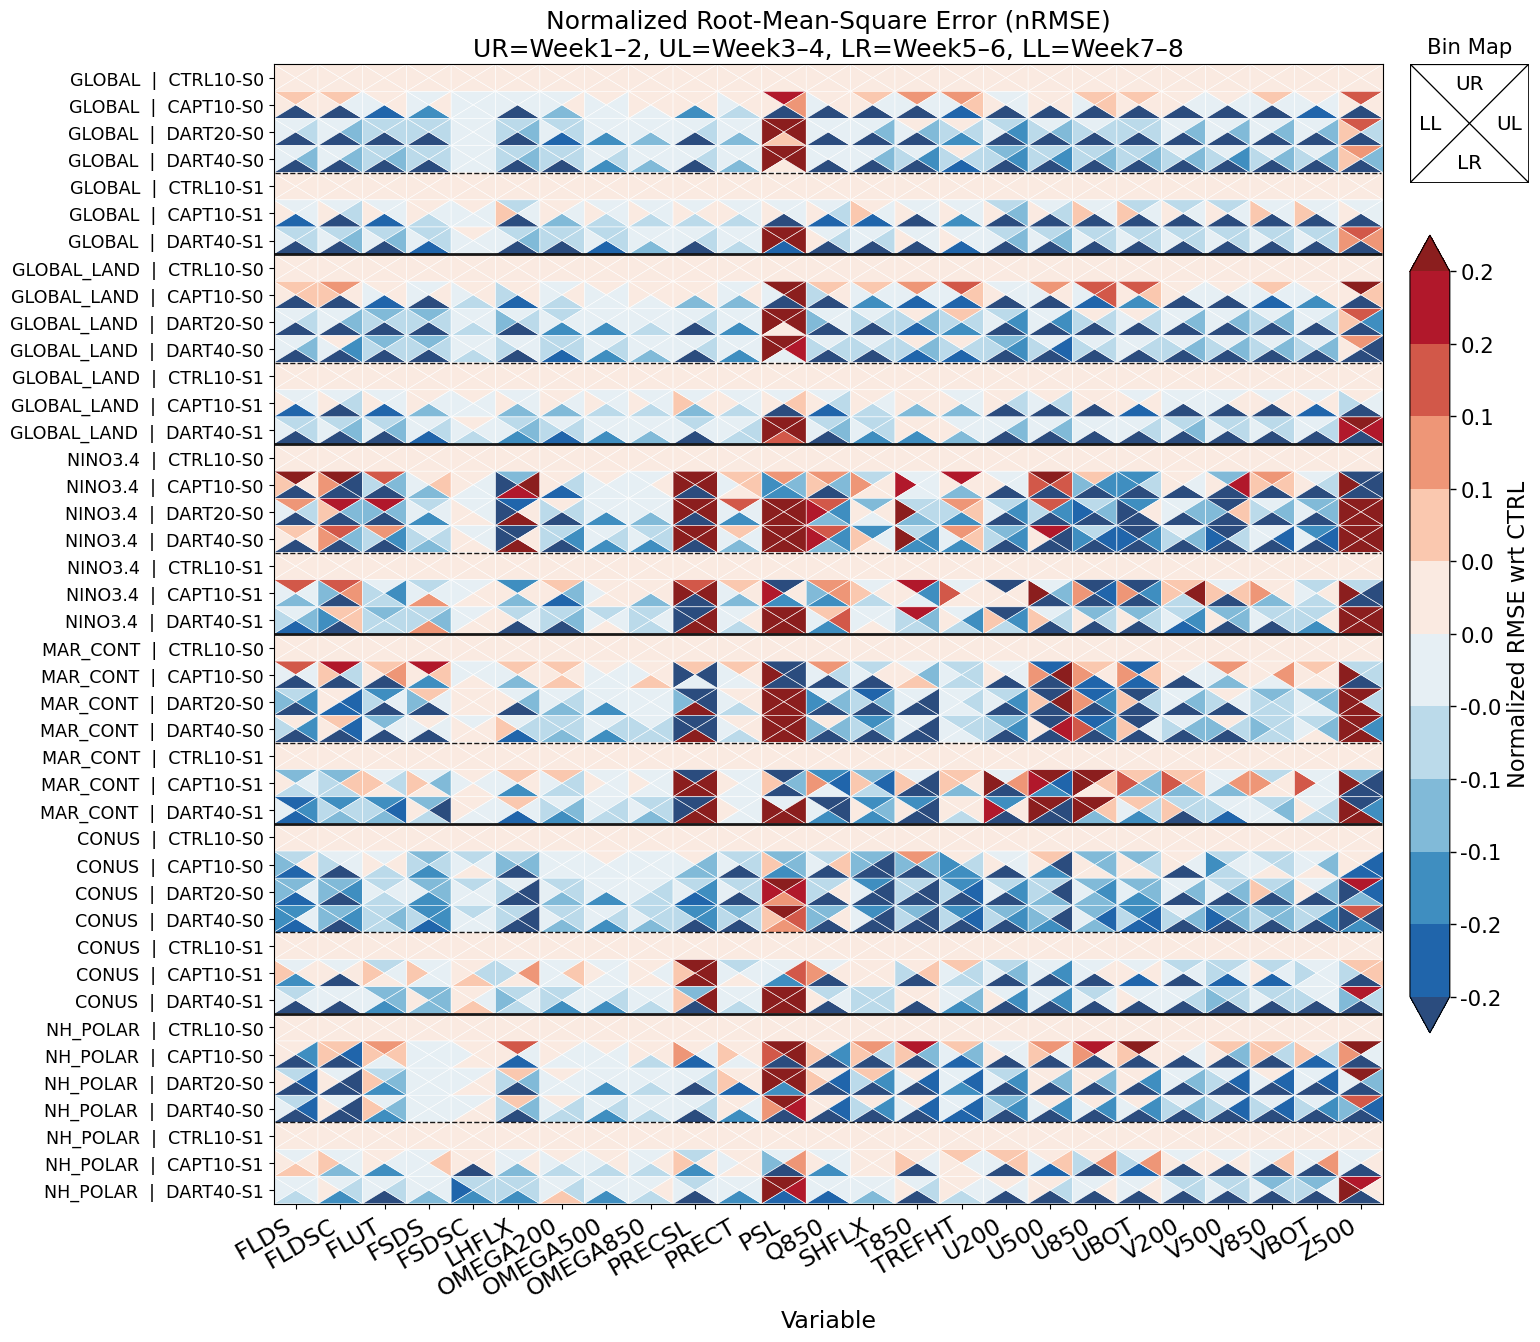

In [52]:
if __name__ == "__main__":
    data_path = Path("/compyfs/zhan391/v3_dart_cda_scratch/diag_output/acc_rmse")
    fig_path = Path("./")
    fig_path.mkdir(parents=True, exist_ok=True)

    exp_list = {
        "Jan2012": dict(
            models=["CTRL10-S0", "CAPT10-S0", "DART20-S0", "DART40-S0"],
            colors=["#7f7f7f", "#000000", "#1f77b4", "#d62728"],  # grey, black, blue, red
            period="201201-201203",
            season="Winter",
            init_month=1,
        ),
        "Jun2012": dict(
            models=["CTRL10-S1","CAPT10-S1", "DART40-S1"],
            colors=["#000000", "#d62728"],  # black, red
            period="201206-201208",
            season="Summer",
            init_month=6,
        ),
    }

    group = "Jan2012"
    freq = "daily"
    run = "fc"
    two_groups = True 
    
    if two_groups : 
        exp_order = (
            "CTRL10-S0",
            "CAPT10-S0",
            "DART20-S0",
            "DART40-S0",
            "CTRL10-S1",
            "CAPT10-S1",
            "DART40-S1",
        )
        s2_start = 4 
        exp_colors = {
            "CTRL10-S0": "#7f7f7f",
            "CAPT10-S0": "#000000",
            "DART20-S0": "#1f77b4",
            "DART40-S0": "#d62728",
            "CAPT10-S1": "#000000",
            "DART40-S1": "#d62728",
        }
    else:
        exp_order = exp_list[group]["models"]
        exp_colors = dict(zip(exp_order, exp_list[group]["colors"]))  # <-- key fix
        s2_start = -99 
        
    var_dict = {
        "UBOT": {"ACC": {"ylim": (0.1, 0.6), "xlim": (0, 60)}, "smooth_days": 0},
        "VBOT": {"ACC": {"ylim": (0.1, 0.6), "xlim": (0, 60)}, "smooth_days": 0},
        "PSL": {"ACC": {"ylim": (0.1, 0.6), "xlim": (0, 60)}, "smooth_days": 0},
        "PRECT": {"ACC": {"ylim": (0.1, 0.6), "xlim": (0, 60)}, "smooth_days": 0},
        "U850": {"ACC": {"ylim": (0.1, 0.6), "xlim": (0, 60)}, "smooth_days": 0},
        "V850": {"ACC": {"ylim": (0.1, 0.6), "xlim": (0, 60)}, "smooth_days": 0},
        "T850": {"ACC": {"ylim": (0.9, 1.0), "xlim": (0, 60)}, "smooth_days": 0},
        "Z500": {"ACC": {"ylim": (0.9, 1.0), "xlim": (0, 60)}, "smooth_days": 0},
        "OMEGA500": {"ACC": {"ylim": (0.1, 0.6), "xlim": (0, 60)}, "smooth_days": 0},
        "U200": {"ACC": {"ylim": (0.1, 0.6), "xlim": (0, 60)}, "smooth_days": 0},
        "V200": {"ACC": {"ylim": (0.1, 0.6), "xlim": (0, 60)}, "smooth_days": 0},
    }
    
    vars_include = (
        "UBOT", "VBOT", "PSL",
        "U850", "V850", "T850", "Q850",
        "U500", "V500", "T500", "Q500", 
        "U200", "V200", "T200", "Q200", 
        "OMEGA850", "OMEGA500", "OMEGA200",
        "Z500", "PRECT", "TREFHT", 
        "PRECSL", "FLUT",
        # Surface fluxes & radiation
        "FLDS", "FLDSC", 
        "FSDS", "FSDSC",
        "LHFLX", "SHFLX",
    )
    
    obs_by_var = {"PRECT": "GPM", "FLUT": "NOAA-OLR"}  
    default_obs = "ERA5"
    
    if two_groups: 
        file_glob = f"s2s_skill_*_{freq}_{run}_*_*.nc"
    else: 
        file_glob = f"s2s_skill_{group}_{freq}_{run}_*_*.nc"

    lead_bins = ((1, 14), (15, 28), (29, 42), (43, 56))
    lead_bin_labels = ("Week1–2", "Week3–4", "Week5–6", "Week7–8")
   
    #metric="ACC"
    #metric="ACC_member_mean"
    #metric="ACC_member_quantile"
    #vmin = 0.0
    #vmax = 1.0
    #nlev = 11 
    #title_label = "Anomaly Correlation Coefficient (ACC)"

    metric="RMSE"
    vmin = -0.2
    vmax = 0.2
    nlev = 11
    title_label = "Normalized Root-Mean-Square Error (nRMSE)"

    bound_split = 0.4 # split where color is from blue to red 
    cb_tvals = np.linspace(vmin, vmax, nlev)
    
    plot_difference = False 
    baseline_exp =  f"CTRL"
    rmse_norm_mode = "baseline" 
    rmse_norm_ctrl_by_group = {
        "Jan2012": "CTRL10-S0",
        "Jun2012": "CTRL10-S1",
    }
    rmse_eps = 1e-12  # avoid divide-by-zero
    quantile_q = 0.9 
    quantile_tol = 1e-3 
    
    guide = True
    guide_loc = "upper right"
    guide_size = 0.08
    edgecolor = "white"
    linewidth = 0.4
    show = True
    xlabel = "Variable"
    ylabel = "" #"Experiment"
    fontz = 18
    regions_include = ("GLOBAL", "GLOBAL_LAND", "NINO3.4", "MAR_CONT", "CONUS", "NH_POLAR")  # <- your regions
    region = "MAR_CONT" 
    
    cfg = S2SSkillPlotConfig(
        skill_dir=data_path,
        obs_by_var = obs_by_var, 
        default_obs = default_obs, 
        file_glob=file_glob,
        out_dir=fig_path,
        exp_order=tuple(exp_order),
        exp_colors=exp_colors,                 # dict(exp->color)
        vars_include=tuple(vars_include),
        lead_bins=lead_bins,
        lead_bin_labels=lead_bin_labels,
        regions_include=regions_include,  # <- your regions
        tag=f"{group}_{freq}_{run}",
        two_groups=two_groups,
        baseline_exp=baseline_exp,
        plot_difference=plot_difference,
        quantile_q = quantile_q,
        quantile_tol= quantile_tol,
        rmse_norm_mode = rmse_norm_mode, 
        rmse_norm_ctrl_by_group = rmse_norm_ctrl_by_group,  
        rmse_eps = rmse_eps, 
    )

    plotter = S2SSkillPlotter(cfg)

    plotter.plot_quadrant_heatmap_all_regions_one_panel(
        metric = metric,
        regions=regions_include,  # optional
        vmin = vmin, 
        vmax = vmax,
        guide = guide,
        guide_loc = guide_loc,
        guide_size = guide_size,
        edgecolor = edgecolor,
        linewidth = linewidth,
        xlabel = xlabel,
        ylabel = ylabel,
        fontz = fontz,
        nlev = nlev,
        s2_start = s2_start, 
        bound_split = bound_split, 
        title_label= title_label, 
        cb_tvals = cb_tvals,
        show=show,
    )

In [ ]:
if __name__ == "__main__":
    data_path = Path("/compyfs/zhan391/v3_dart_cda_scratch/diag_output/acc_rmse")
    fig_path = Path("./")
    fig_path.mkdir(parents=True, exist_ok=True)

    exp_list = {
        "Jan2012": dict(
            models=["CTRL10-S0", "CAPT10-S0", "DART20-S0", "DART40-S0"],
            colors=["#7f7f7f", "#000000", "#1f77b4", "#d62728"],  # grey, black, blue, red
            period="201201-201203",
            season="Winter",
            init_month=1,
        ),
        "Jun2012": dict(
            models=["CAPT10-S1", "DART40-S1"],
            colors=["#000000", "#d62728"],  # black, red
            period="201206-201208",
            season="Summer",
            init_month=6,
        ),
    }

    group = "Jan2012"
    freq = "daily"
    run = "fc"
    
    exp_order = exp_list[group]["models"]
    exp_colors = dict(zip(exp_order, exp_list[group]["colors"]))  # <-- key fix

    var_dict = {
        "UBOT": {"ACC": {"ylim": (0.1, 0.6), "xlim": (0, 60)}, "smooth_days": 0},
        "VBOT": {"ACC": {"ylim": (0.1, 0.6), "xlim": (0, 60)}, "smooth_days": 0},
        "PSL": {"ACC": {"ylim": (0.1, 0.6), "xlim": (0, 60)}, "smooth_days": 0},
        "PRECT": {"ACC": {"ylim": (0.1, 0.6), "xlim": (0, 60)}, "smooth_days": 0},
        "U850": {"ACC": {"ylim": (0.1, 0.6), "xlim": (0, 60)}, "smooth_days": 0},
        "V850": {"ACC": {"ylim": (0.1, 0.6), "xlim": (0, 60)}, "smooth_days": 0},
        "T850": {"ACC": {"ylim": (0.9, 1.0), "xlim": (0, 60)}, "smooth_days": 0},
        "Z500": {"ACC": {"ylim": (0.9, 1.0), "xlim": (0, 60)}, "smooth_days": 0},
        "OMEGA500": {"ACC": {"ylim": (0.1, 0.6), "xlim": (0, 60)}, "smooth_days": 0},
        "U200": {"ACC": {"ylim": (0.1, 0.6), "xlim": (0, 60)}, "smooth_days": 0},
        "V200": {"ACC": {"ylim": (0.1, 0.6), "xlim": (0, 60)}, "smooth_days": 0},
    }

    vars_include = (
        "UBOT", "VBOT", "PSL", "PRECT", "U850", "V850", "T850", "Q850",
        "Z500", "OMEGA500", "U200", "V200",
    )
    
    vars_include = (
        "UBOT", "VBOT", "PSL", "U850", "V850", "T925", "T850", "Q925", "Q850",
        "Z500"
    )

    obs_by_var = {"PRECT": "GPM"}  
    default_obs = "ERA5"
    file_glob = f"s2s_skill_{group}_{freq}_{run}_*_*.nc"

    lead_bins = ((1, 14), (15, 28), (29, 42), (43, 56))
    lead_bin_labels = ("Week1–2", "Week3–4", "Week5–6", "Week7–8")

    metric="ACC"
    vmin = 0.0
    vmax = 1.0
    guide = True
    guide_loc = "upper right"
    guide_size = 0.13
    edgecolor = "white"
    linewidth = 0.4
    show = True
    nlev = 10
    xlabel = "Variable"
    ylabel = "" #"Experiment"
    fontz = 14
    title_label = "Anomaly Correlation Coefficient (ACC)"
    regions_include = ("GLOBAL", "GLOBAL_LAND", "NINO3.4", "MAR_CONT", "CONUS", "NH_POLAR")  # <- your regions
    region = "MAR_CONT" 
    
    cfg = S2SSkillPlotConfig(
        skill_dir=data_path,
        obs_by_var = obs_by_var, 
        default_obs = default_obs, 
        file_glob=file_glob,
        out_dir=fig_path,
        exp_order=tuple(exp_order),
        exp_colors=exp_colors,                 # dict(exp->color)
        vars_include=tuple(vars_include),
        lead_bins=lead_bins,
        lead_bin_labels=lead_bin_labels,
        regions_include=regions_include,  # <- your regions
        tag=f"{group}_{freq}_{run}_{obs}",
    )

    plotter = S2SSkillPlotter(cfg)

    #
    plotter.plot_quadrant_heatmap_all_regions_one_panel(
        metric = metric,
        regions=regions_include,  # optional
        vmin = vmin, 
        vmax = vmax,
        guide = guide,
        guide_loc = guide_loc,
        guide_size = guide_size,
        edgecolor = edgecolor,
        linewidth = linewidth,
        xlabel = xlabel,
        ylabel = ylabel,
        fontz = fontz,
        nlev = nlev,
        title_label= title_label, 
        show=show,
    )
    print(xxxx)
    
    # All-in-one triangle/quadrant heatmap
    plotter.plot_quadrant_heatmap(
        region=region,
        metric = metric,
        vmin = vmin, 
        vmax = vmax,
        guide = guide,
        guide_loc = guide_loc,
        guide_size = guide_size,
        edgecolor = edgecolor,
        linewidth = linewidth,
        xlabel = xlabel,
        ylabel = ylabel,
        fontz = fontz,
        nlev = nlev,
        title_label= title_label, 
        show=show,
    )
    

In [ ]:
if __name__ == "__main__":
    data_path = Path("/compyfs/zhan391/v3_dart_cda_scratch/diag_output/acc_rmse")
    fig_path = Path("./")
    fig_path.mkdir(parents=True, exist_ok=True)

    exp_list = {
        "Jan2012": dict(
            models=["CTRL10-S0", "CAPT10-S0", "DART20-S0", "DART40-S0"],
            colors=["#7f7f7f", "#000000", "#1f77b4", "#d62728", ],
            period="201201-201203",
            season="Winter",
            init_month=1,
        ),
        "Jun2012": dict(
            models=["CAPT10-S1", "DART40-S1"],
            colors=["#000000", "#1f77b4", "#d62728", ],
            period="201206-201208",
            season="Summer",
            init_month=6,
        ),
    }
    
    group = "Jan2012"
    freq = "daily"
    run = "fc"
    obs = "ERA5"

    exp_order = exp_list[group]["models"]
    exp_colors = exp_list[group]["colors"]
    var_dict = {
        "UBOT": {"ACC": [(0.1,0.6),(0,60)], "RMSE": (0.0,None), "smooth_days": 0},
        "VBOT": {"ACC": [(0.1,0.6),(0,60)], "RMSE": (0.0,None), "smooth_days": 0},
        "PSL": {"ACC": [(0.1,0.6),(0,60)], "RMSE": (0.0,None), "smooth_days": 0},
        "PRECT": {"ACC": [(0.1,0.6),(0,60)], "RMSE": (0.0,None), "smooth_days": 0},
        "U850": {"ACC": [(0.1,0.6),(0,60)], "RMSE": (0.0,None), "smooth_days": 0},
        "V850": {"ACC": [(0.1,0.6),(0,60)], "RMSE": (0.0,None), "smooth_days": 0},
        "T850": {"ACC": [(0.9,1.0),(0,60)], "RMSE": (0.0,None), "smooth_days": 0},
        "Z500": {"ACC": [(0.9,1.0),(0,60)], "RMSE": (0.0,None), "smooth_days": 0},
        "OMEGA500": {"ACC": [(0.1,0.6),(0,60)], "RMSE": (0.0,None), "smooth_days": 0},
        "U200": {"ACC": [(0.1,0.6),(0,60)], "RMSE": (0.0,None), "smooth_days": 0},
        "V200": {"ACC": [(0.1,0.6),(0,60)], "RMSE": (0.0,None), "smooth_days": 0},
    }
    vars_include = (
        "UBOT", "VBOT", "PSL", "PRECT", "U850", "V850", "T850", "Q850",
        "Z500", "OMEGA500", "U200", "V200",
    )

    smooth_days = 0
    time_max = 60
    lead_bins = ((1, 14), (15, 28), (29, 42), (43, 56))
    lead_bin_labels = ("Week1–2", "Week3–4", "Week5–6", "Week7–8")

    var = "T850"
    shc_metric = "ACC"
    cur_metric = "ACC"
    bar_metric = "ACC"
    bar_use_quantiles = True
    line_type="ens_mean_std"          
    
    ylim = var_dict[var][bar_metric][0]
    xlim = var_dict[var][bar_metric][1]
    
    # Make sure we only pick up the selected group’s files
    file_glob = f"s2s_skill_{group}_{freq}_{run}_{obs}_*.nc"
    
    cfg = S2SSkillPlotConfig(
        skill_dir=data_path,
        file_glob=file_glob,
        out_dir=fig_path,
        exp_order=tuple(exp_order),
        exp_colors=exp_colors,
        vars_include=tuple(vars_include),
        smooth_days=smooth_days,
        time_max=time_max,
        lead_bins=lead_bins,
        lead_bin_labels=lead_bin_labels,
        bar_metric=bar_metric,
        bar_use_quantiles=bar_use_quantiles,
        # IMPORTANT: prevents overwriting outputs between Jan/Jun and records provenance in filenames
        tag=f"{group}_{freq}_{run}_{obs}",
        # Choose one:
        line_type=line_type,         # ensemble-mean deterministic skill
        xlim=xlim,
        ylim=ylim
    )

    plotter = S2SSkillPlotter(cfg)
        
    # Single variable quick looks
    plotter.plot_skill_curves(var, metrics=(cur_metric,), show=True)
    plotter.plot_week_binned_bars(var, metric=bar_metric, show=True)
    plotter.plot_shock_metric(var, metric=shc_metric, show=True)

    # Batch all
    # plotter.make_all(do_curves=True, do_bars=True, do_shock=True, show=False)
    